# Dataset

This notebook checks that the precomputed SHARP Doppler traces are available under `data/doppler_traces`. If the folder is missing, it downloads `doppler_traces.zip` from Google Drive and extracts it into the expected layout.

In [40]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from download import ensure_doppler_traces

DOPPLER_DIR = PROJECT_ROOT / "data" / "doppler_traces_pi"

(41037, 100)


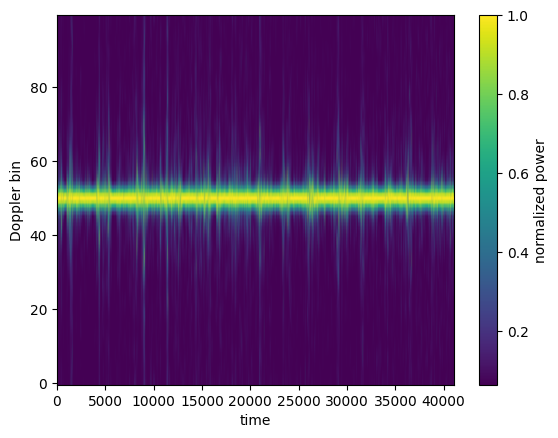

In [41]:
import os
import pickle
import matplotlib.pyplot as plt

pi1a_dir = DOPPLER_DIR / "PI-1a"
files = [f for f in os.listdir(pi1a_dir) if f.endswith(".txt")]

file_idx = 5  # Select a file

# Load and plot the selected file
path = pi1a_dir / files[file_idx]
with open(path, "rb") as f:
    trace = pickle.load(f)

print(trace.shape)

plt.imshow(trace.T, aspect="auto", origin="lower", cmap="viridis")
plt.xlabel("time")
plt.ylabel("Doppler bin")
plt.colorbar(label="normalized power")
plt.show()

In [42]:
from torch import no_grad

def eval_with_fusion(model, dataloader, loss_fn, fusion_type, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            logits = model(x, fusion=fusion_type)

            batch_loss = loss_fn(logits, y)

            total_loss += batch_loss.item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    return {
        "loss": total_loss / total,
        "acc": correct / total,
    }

# Training

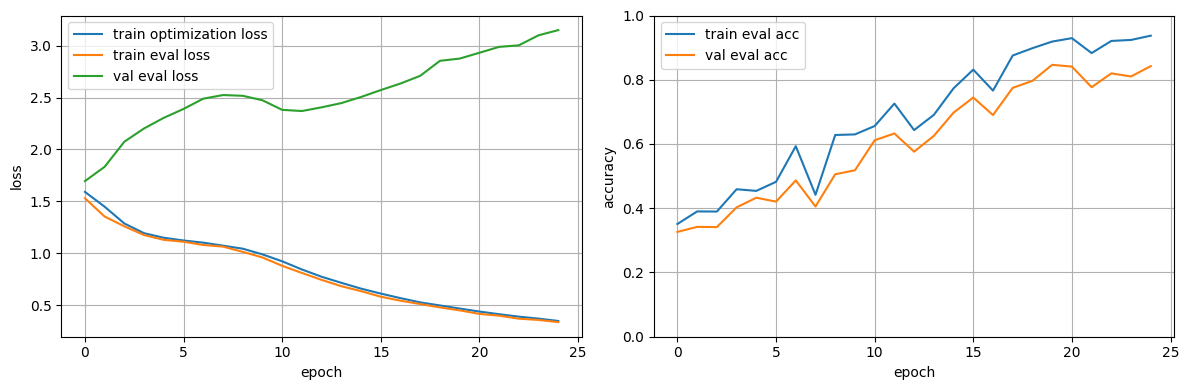

epoch: 025
  train_opt_loss  : 0.3476
  train_eval_loss : 0.3365
  val_eval_loss   : 3.1494
  train_acc       : 0.9372
  val_acc         : 0.8423
  best_val_acc    : 0.8464 @ epoch 20


In [43]:
import torch
from torch.cuda import is_available
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
import copy

from models.base_model import MultiAntennaModel, SingleAntennaModel
from dataset import DopplerWindowDataset

EPOCHS = 25
RUN_NAME = "pi_5persons_same_domain_sharp_model"

PERSONS = ["p03", "p05", "p06", "p07", "p08"]

TRAIN_SCENARIOS = ["PI-1a"]
TEST_SCENARIOS = ["PI-1a"]

FUSION_TYPE = "mean"

device = "cuda" if is_available() else "cpu"

single_antenna_model = SingleAntennaModel(num_classes=len(PERSONS)).to(device)
model = MultiAntennaModel(single_antenna_model).to(device)

train_dataset = DopplerWindowDataset(DOPPLER_DIR, split=(0, 0.6), scenarios=TRAIN_SCENARIOS, labels=PERSONS)
val_dataset = DopplerWindowDataset(DOPPLER_DIR, split=(0.6, 0.8), scenarios=TEST_SCENARIOS, labels=PERSONS)

# Materialize LazyLinear before optimizer creation
with no_grad():
    dummy = train_dataset[0][0].unsqueeze(0).to(device)  # (1, num_antennas, num_bins, num_frames)
    _ = model.forward_antennas(dummy)

print("Number of parameters:", sum(p.numel() for p in single_antenna_model.parameters()))

optimizer = Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    eps=1e-7,
    weight_decay=0.0,
)

model.to(device)

loss = CrossEntropyLoss()

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

best_val_acc = 0.0
best_epoch = -1
best_state = None

history = {
    "train_optimization_loss": [],
    "train_eval_loss": [],
    "val_eval_loss": [],
    "train_eval_acc": [],
    "val_eval_acc": [],
}


def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_optimization_loss"], label="train optimization loss")
    axes[0].plot(history["train_eval_loss"], label="train eval loss")
    axes[0].plot(history["val_eval_loss"], label="val eval loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history["train_eval_acc"], label="train eval acc")
    axes[1].plot(history["val_eval_acc"], label="val eval acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    fig.tight_layout()
    return fig, axes

for epoch in range(EPOCHS):
    model.train()

    running_loss_sum = 0.0
    total_train_samples = 0

    for x, y in train_dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model.forward(x, fusion=FUSION_TYPE) # (batch_size, num_classes)

        train_loss = loss(logits, y)
        train_loss.backward()
        optimizer.step()

        running_loss_sum += train_loss.item() * x.size(0)
        total_train_samples += x.size(0)

    train_optimization_loss = running_loss_sum / total_train_samples

    train_metrics = eval_with_fusion(model, train_dataloader, loss, FUSION_TYPE, device)
    val_metrics = eval_with_fusion(model, val_dataloader, loss, FUSION_TYPE, device)

    history["train_optimization_loss"].append(train_optimization_loss)
    history["train_eval_loss"].append(train_metrics["loss"])
    history["val_eval_loss"].append(val_metrics["loss"])

    history["train_eval_acc"].append(train_metrics["acc"])
    history["val_eval_acc"].append(val_metrics["acc"])

    if val_metrics["acc"] > best_val_acc:
        best_val_acc = val_metrics["acc"]
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())


    clear_output(wait=True)

    fig, axes = plot_training_curves(history)
    plt.show()

    print(
        f"epoch: {epoch + 1:03d}\n"
        f"  train_opt_loss  : {train_optimization_loss:.4f}\n"
        f"  train_eval_loss : {train_metrics['loss']:.4f}\n"
        f"  val_eval_loss   : {val_metrics['loss']:.4f}\n"
        f"  train_acc       : {train_metrics['acc']:.4f}\n"
        f"  val_acc         : {val_metrics['acc']:.4f}\n"
        f"  best_val_acc    : {best_val_acc:.4f} @ epoch {best_epoch}"
    )

# Evaluation artifacts

Save the best model weights and inspect the person-ID confusion matrix.

In [44]:
from datetime import datetime
import numpy as np


def collect_predictions(model, dataloader, device, fusion=FUSION_TYPE):
    model.eval()

    y_true = []
    y_pred = []

    with no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model(x, fusion=fusion)
            preds = logits.argmax(dim=1).cpu()

            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(preds.numpy().tolist())

    return np.asarray(y_true), np.asarray(y_pred)


def make_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true_idx, pred_idx in zip(y_true, y_pred):
        cm[int(true_idx), int(pred_idx)] += 1
    return cm


def plot_confusion_matrix(cm, labels, normalize=True, title="PI confusion matrix"):
    values = cm.astype(float)
    if normalize:
        row_sums = values.sum(axis=1, keepdims=True)
        values = np.divide(values, row_sums, out=np.zeros_like(values), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(values, cmap="Blues", vmin=0, vmax=1 if normalize else None)
    fig.colorbar(im, ax=ax, label="recall" if normalize else "count")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("predicted identity")
    ax.set_ylabel("true identity")
    ax.set_title(title)

    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            text = f"{values[row, col]:.2f}" if normalize else str(cm[row, col])
            color = "white" if values[row, col] > 0.5 else "black"
            ax.text(col, row, text, ha="center", va="center", color=color, fontsize=8)

    fig.tight_layout()
    return fig, ax


def save_checkpoint(model, path, labels, config, metrics):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "labels": list(labels),
        "config": config,
        "metrics": metrics,
        "history": history,
    }
    torch.save(checkpoint, path)
    return path


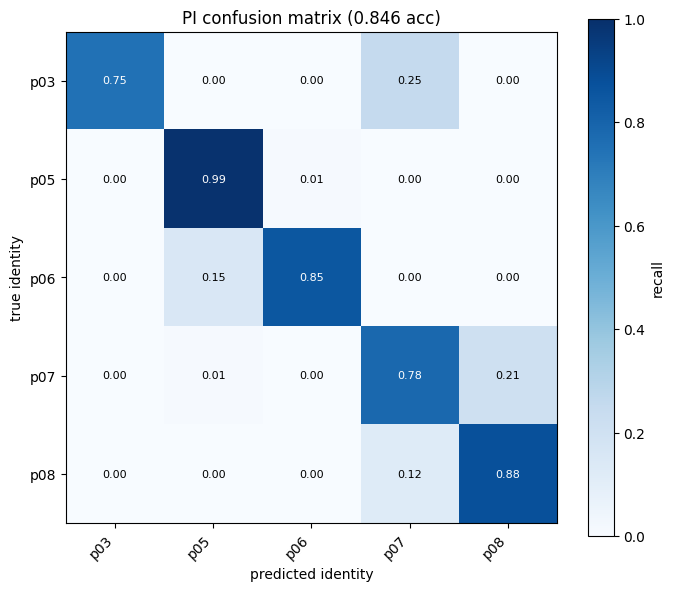

Saved run directory: C:\Users\gianm\Development\wifi-doppler-har\outputs\pi_classification\pi_5persons_same_domain_sharp_model_20260525_152103
Saved checkpoint: C:\Users\gianm\Development\wifi-doppler-har\outputs\pi_classification\pi_5persons_same_domain_sharp_model_20260525_152103\model.pt
Saved training curves: C:\Users\gianm\Development\wifi-doppler-har\outputs\pi_classification\pi_5persons_same_domain_sharp_model_20260525_152103\training_curves.png
Saved confusion matrix: C:\Users\gianm\Development\wifi-doppler-har\outputs\pi_classification\pi_5persons_same_domain_sharp_model_20260525_152103\confusion_matrix.png
{'best_epoch': 20, 'best_val_acc': 0.8464163822525598, 'restored_val_acc': 0.8464163822525598}


In [45]:
if best_state is not None:
    model.load_state_dict(best_state)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = PROJECT_ROOT / "outputs" / "pi_classification" / f"{RUN_NAME}_{timestamp}"
run_dir.mkdir(parents=True, exist_ok=False)

y_true, y_pred = collect_predictions(model, val_dataloader, device, fusion=FUSION_TYPE)
cm = make_confusion_matrix(y_true, y_pred, num_classes=len(PERSONS))
val_acc = float((y_true == y_pred).mean())

checkpoint_path = run_dir / "model.pt"
confusion_matrix_path = run_dir / "confusion_matrix.png"
training_curves_path = run_dir / "training_curves.png"

config = {
    "doppler_dir": str(DOPPLER_DIR),
    "train_scenarios": TRAIN_SCENARIOS,
    "test_scenarios": TEST_SCENARIOS,
    "labels": PERSONS,
    "epochs": EPOCHS,
    "window_size": train_dataset.window_size,
    "window_stride": train_dataset.window_stride,
    "fusion": FUSION_TYPE,
}
metrics = {
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "restored_val_acc": val_acc,
}

save_checkpoint(model, checkpoint_path, PERSONS, config, metrics)

curves_fig, curves_axes = plot_training_curves(history)
curves_fig.savefig(training_curves_path, dpi=150)
plt.close(curves_fig)


fig, ax = plot_confusion_matrix(
    cm,
    PERSONS,
    normalize=True,
    title=f"PI confusion matrix ({val_acc:.3f} acc)",
)
fig.savefig(confusion_matrix_path, dpi=150)
plt.show()

print(f"Saved run directory: {run_dir}")
print(f"Saved checkpoint: {checkpoint_path}")
print(f"Saved training curves: {training_curves_path}")
print(f"Saved confusion matrix: {confusion_matrix_path}")
print(metrics)
